# Hantavirus network 
This code will create a network graph (Conversational Network) for bluesky data on the hantavirus 

---
### Import data and Libraries

In [4]:
#Import all required libraries
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import community as community_louvain
from collections import Counter
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import sys
import string
import re
import nltk
import codecs
import emoji
import gensim
import random
import numpy as np
from datetime import datetime, date, timedelta
from collections import Counter
from collections import defaultdict
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer 
from nltk import bigrams
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import DetectorFactory
from gensim.models import CoherenceModel
from gensim.models import LdaModel
from wordcloud import WordCloud
from gensim import corpora
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [5]:
#Load the data
graph_df = pd.read_csv("Bluesky_dataset_UG11.csv")

#Fill Missing replying_to columns as ROOT
#This is missing for root posts (not a reply or comment)
graph_df["replying_to"] = graph_df["replying_to"].fillna("ROOT")

#Drop all null values and ensure data is in correct type
graph_df = graph_df.dropna(subset=["author", "replying_to", "depth"])
graph_df = graph_df.astype({"author": str, "replying_to": str, "depth": int})

In [6]:
#View the data to ensure it has been correctly imported
graph_df

,uri,author,replying_to,text,created_at,depth,likes,reposts,period
0,at://did:plc:zxh6uh5wehlxl3mmos7bz372/app.bsky...,yourcanadiangf.bsky.social,robdelaney.bsky.social,did he do Elon's botched Dong implant?,2026-05-15T16:15:34.751Z,1,0,0,NaN
1,at://did:plc:zwxw7hwlxh6exd7mo3wbqvos/app.bsky...,fluffythecruel.bsky.social,robdelaney.bsky.social,I’m at the penile implant specialist. I’m at t...,2026-05-15T11:08:07.165Z,1,3,0,NaN
2,at://did:plc:zqgf4oiy74m2exchgf4vjbyb/app.bsky...,marcosantana.bsky.social,robdelaney.bsky.social,A twofer,2026-05-15T12:44:58.919Z,1,0,0,NaN
3,at://did:plc:zqgf4oiy74m2exchgf4vjbyb/app.bsky...,marcosantana.bsky.social,robdelaney.bsky.social,A twofer.,2026-05-15T12:44:00.948Z,1,0,0,NaN
4,at://did:plc:zq4y36m255l4tbsvef4yblsk/app.bsky...,twinsfan81.bsky.social,robdelaney.bsky.social,"They are trying to kill all of us, aren’t they.",2026-05-15T14:15:38.513Z,1,1,0,NaN
...,...,...,...,...,...,...,...,...,...
14446,at://did:plc:jhzknzmzilaq4hn64t37da5b/app.bsky...,matthewjohnson.bsky.social,matthewjohnson.bsky.social,The MV Hondius is currently in Cape Verde so I...,2026-05-03T19:14:41.660Z,1,1,1,1.0
14447,at://did:plc:jhzknzmzilaq4hn64t37da5b/app.bsky...,matthewjohnson.bsky.social,matthewjohnson.bsky.social,I almost booked my Antarctica trip on the MV H...,2026-05-03T19:18:32.473Z,2,2,0,1.0
14448,at://did:plc:yzuv34p75egge7tatgia5btu/app.bsky...,ldermer.bsky.social,ROOT,Pretty sure I remember this hantavirus outbrea...,2026-05-04T02:53:54.760Z,0,1,0,1.0
14449,at://did:plc:yzuv34p75egge7tatgia5btu/app.bsky...,ldermer.bsky.social,ldermer.bsky.social,(That or it was a couple years later and we we...,2026-05-04T02:54:31.365Z,1,1,0,1.0


---
### Build directed & Weighted Graph

In [8]:
#Code adapted from wk8 lab
#Build mappings
id2author = dict(zip(graph_df["uri"], graph_df["author"]))

#Infer root post author from commentsreplies where depth == 0
thread2author = dict(graph_df[graph_df["depth"] == 0].groupby("uri")["author"].first())

#Count identifiable posts per author
post_counts = pd.Series(thread2author).value_counts().to_dict()


In [9]:
#Output the users with the most posts
post_counts

{'reuters.com': 27,
 'apnews.com': 20,
 'theguardian.com': 18,
 'nytimes.com': 18,
 'realtuckfrumper.bsky.social': 17,
 'plaguepoems.bsky.social': 13,
 'thev.bsky.social': 13,
 'bcwildfirewkly.bsky.social': 11,
 'krutikakuppalli.bsky.social': 11,
 'chantzy.bsky.social': 10,
 'pbsnews.org': 10,
 'sciam.bsky.social': 9,
 'cnn.com': 9,
 'ecdc.europa.eu': 9,
 'nbcnews.com': 9,
 'datareport.bsky.social': 9,
 'thecovidinfoguy.bsky.social': 8,
 'onestpress.onestnetwork.com': 8,
 'boghuma.bsky.social': 7,
 'cidrap.bsky.social': 7,
 'aljazeera.com': 7,
 'canadahealthwatch.ca': 7,
 'gavinyamey.bsky.social': 6,
 'npr.org': 6,
 'bloomberg.com': 6,
 'who.int': 6,
 'rimaanabtawi.bsky.social': 6,
 'mackayim.bsky.social': 6,
 'tryangregory.bsky.social': 6,
 'en.afp.com': 6,
 'marcveld.bsky.social': 6,
 'mcbridetd.bsky.social': 6,
 'ylepidemiologist.bsky.social': 6,
 'bbcnews-world-rss.bsky.social': 5,
 'thailandmedical.bsky.social': 5,
 'washingtonpost.com': 5,
 'davidbflower.bsky.social': 5,
 'kakape

In [10]:
#Code adapted from wk8 lab
#Create a directed weighted graph
#Direction is who replied to who
#Weight is how many interactions of that direction
replyGraph = nx.DiGraph()

#Add user nodes with postNum
for user in graph_df["author"].unique():
    replyGraph.add_node(user,postNum=int(post_counts.get(user, 0)))

#Add directed weighted reply edges
for _, row in graph_df.iterrows():
    user = row["author"]
    parent_id = row["replying_to"]

    #Determine if post is original post
    #We do not want to include root posts as a reply to a root post
    if parent_id == 'ROOT':
        parent_user = user

    #Replies to post or another reply
    else:
        parent_user = parent_id

    #Add edge: user -> parent_user
    if parent_user and parent_user != user:
        if replyGraph.has_edge(user, parent_user):
            replyGraph[user][parent_user]["replyNum"] += 1
        else:
            replyGraph.add_edge(user, parent_user, replyNum=1)

#Check graph
print("Nodes:", replyGraph.number_of_nodes())
print("Edges:", replyGraph.number_of_edges())

#Save the graph to a file
nx.write_graphml(replyGraph, "400_test_reply_graph.graphml")

Nodes: 8755
Edges: 10883


---
### Centrality

In [12]:
#Code adapted from wk8 lab
sFileName = "400_test_reply_graph.graphml"

#Reading file back in
replyGraph = nx.readwrite.read_graphml(sFileName)

#Computing the degree centrality and plotting it
lDegCentrality = nx.degree_centrality(replyGraph)

#Computing the Eigenvector centrality and plotting it
lEigenVectorCentrality = nx.eigenvector_centrality(replyGraph, max_iter=5000)

#Computing the Katz centrality and plotting it
lKatzCentrality = nx.katz_centrality(replyGraph, alpha=0.01, max_iter=5000)

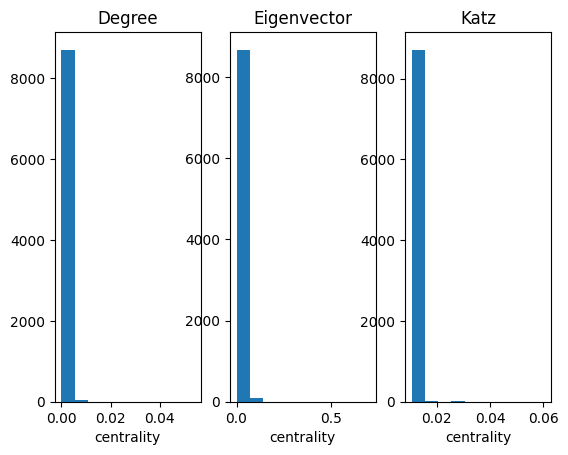

In [13]:
#Code adapted from wk8 lab
#Plot histograms for centrality measures
#Degree centrality
plt.subplot(1,3,1)
plt.hist(list(lDegCentrality.values()))
plt.title('Degree')
plt.xlabel('centrality')
#Eigenvector centrality
plt.subplot(1, 3, 2)
plt.hist(list(lEigenVectorCentrality.values()))
plt.title('Eigenvector')
plt.xlabel('centrality')
#Katz centrality
plt.subplot(1, 3, 3)
plt.hist(list(lKatzCentrality.values()))
plt.title('Katz')
plt.xlabel('centrality')

plt.show()

In [14]:
#Code adapted from wk8 lab
#Update the node attributes with centrality
#Eigenvector centrality, stored in node attribute 'eigen'
for nodeId, cent in lEigenVectorCentrality.items():
    replyGraph.nodes[nodeId]['eigen'] = float(cent)

#Katz centrality, stored in node attribute 'katz'
for nodeId, cent in lKatzCentrality.items():
    replyGraph.nodes[nodeId]['katz'] = float(cent)
    
#Write out graph to new file 
nx.readwrite.write_graphml(replyGraph, 'mod' + sFileName, infer_numeric_types=True)

#Compute and print clustering coefficient 
print('Gloabl clustering coefficient/transitivit = {}'.format(nx.transitivity(replyGraph)))

#Compute and print components (weak and strong)
print('number of strongly connected components = {}'.format(nx.number_strongly_connected_components(replyGraph)))
print('number of weakly connected components = {}'.format(nx.number_weakly_connected_components(replyGraph)))

#Compute and print bridges
print(list(nx.bridges(replyGraph.to_undirected())))

Gloabl clustering coefficient/transitivit = 0.03332684635594045
number of strongly connected components = 7656
number of weakly connected components = 586
[('yourcanadiangf.bsky.social', 'robdelaney.bsky.social'), ('fluffythecruel.bsky.social', 'robdelaney.bsky.social'), ('twinsfan81.bsky.social', 'robdelaney.bsky.social'), ('mrfuzzyfart.bsky.social', 'robdelaney.bsky.social'), ('muralgoblin.bsky.social', 'robdelaney.bsky.social'), ('laurenflans.bsky.social', 'robdelaney.bsky.social'), ('footballlibrettist.bsky.social', 'robdelaney.bsky.social'), ('youdontknowme46.bsky.social', 'robdelaney.bsky.social'), ('maudhd.bsky.social', 'robdelaney.bsky.social'), ('zer0f0x.bsky.social', 'robdelaney.bsky.social'), ('jimmylabe.bsky.social', 'robdelaney.bsky.social'), ('wndlb.bsky.social', 'fellowhuman666.bsky.social'), ('wndlb.bsky.social', 'jennifernuzzo.bsky.social'), ('wndlb.bsky.social', 'cestith.bsky.social'), ('pollycurley.bsky.social', 'robdelaney.bsky.social'), ('knbabyks.bsky.social', 'ro

In [15]:
#Get the top 10 most central nodes (Eigenvector)
sortedEigen = sorted(lEigenVectorCentrality.items(), key=lambda x: x[1], reverse=True)
print(sortedEigen[:10])

[('sailorrooscout.bsky.social', 0.7027969363702053), ('drdonna1.bsky.social', 0.08644500097553229), ('neiot.bsky.social', 0.07978553009867927), ('lizdynan.bsky.social', 0.07879365169989241), ('chrisholly.bsky.social', 0.07879313188440608), ('uniondesign.bsky.social', 0.0787809492837251), ('deltadagger.bsky.social', 0.07878094928372509), ('lluxlokii.bsky.social', 0.07876906592942022), ('thebeastcub.bsky.social', 0.07781338431758017), ('asuvir.bsky.social', 0.07781338431758017)]


In [16]:
#Get the top 10 most central nodes (Katz)
sortedKatz = sorted(lKatzCentrality.items(), key=lambda x: x[1], reverse=True)
print(sortedKatz[:10])

[('meidastouch.com', 0.06032099727867152), ('atrupar.com', 0.048953772257577785), ('cwebbonline.com', 0.0404364988121122), ('acyn.bsky.social', 0.03789577345094115), ('forbes.com', 0.030378205855054692), ('muellershewrote.com', 0.029215600901422525), ('downwithdan.bsky.social', 0.028603675192459203), ('briantylercohen.bsky.social', 0.028113346523725324), ('robdelaney.bsky.social', 0.027546568286211038), ('sailorrooscout.bsky.social', 0.025972996010236976)]


In [17]:
#Code adapted from: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality.html
#Calculating betweeness centrality for entire network
betweenness_dict = nx.betweenness_centrality(replyGraph, normalized=True)

#Output sorted betweness centrality scores (Highest -> Lowest)
sorted(betweenness_dict.items(), key=lambda x: x[1], reverse=True)

[('elizabethjacobs.bsky.social', 0.004900379496842745),
 ('njbbari3.bsky.social', 0.0045599563676863636),
 ('sailorrooscout.bsky.social', 0.004133660841252413),
 ('tryangregory.bsky.social', 0.003315129674524734),
 ('aetiology.bsky.social', 0.002995058062970311),
 ('seancj.bsky.social', 0.002922254441037396),
 ('mackayim.bsky.social', 0.0028076045259800082),
 ('andreastudiescovid.bsky.social', 0.002315121647401715),
 ('beansproutsmom.bsky.social', 0.0022555746696699304),
 ('chantzy.bsky.social', 0.002216382141681288),
 ('sarabjustone.bsky.social', 0.002149080156017484),
 ('lizdynan.bsky.social', 0.002091956076090921),
 ('ockinger.bsky.social', 0.0020542871695011697),
 ('coffeemagic24.bsky.social', 0.0020020889744768603),
 ('katiehowland.bsky.social', 0.0018926982732983667),
 ('nursegenius1019.bsky.social', 0.0016924269012699087),
 ('melodyschreiber.com', 0.0016878702932691732),
 ('theonlyrealtmcmaui.bsky.social', 0.001624074077025097),
 ('dj1au.bsky.social', 0.001385498131525377),
 ('s

---
### Community detection in graphs

In [19]:
#Code adapted from wk9 lab
#Detect communities in graphs
#Read the updated graph with centrality
G = nx.read_graphml("mod400_test_reply_graph.graphml")

#Louvain
partition = community_louvain.best_partition(G.to_undirected())
for node, comm_id in partition.items():
    G.nodes[node]["louvain"] = comm_id

#CPM
k = 3
cpm_comms = list(nx.algorithms.community.k_clique_communities(G.to_undirected(), k))
for i, comm in enumerate(cpm_comms):
    for node in comm:
        G.nodes[node]["cpm"] = i

#Write to a new graph
nx.write_graphml(G, "400_test_communities.graphml")

---
#### Centrality Per Community

In [21]:
#Load community graph saved above 
G = nx.read_graphml("400_test_communities.graphml")

#Assinging Nodes to a community as saved in above graph 
community_assign = {node: data["louvain"] for node, data in G.nodes(data=True) if "louvain" in data}

In [22]:
#Create a list per community of all nodes
#To be used to create subgraphs
community_users = {}
for node, community_id in community_assign.items():
    if community_id not in community_users:
        community_users[community_id] = []
    community_users[community_id].append(node)
community_users

{6: ['yourcanadiangf.bsky.social',
  'fluffythecruel.bsky.social',
  'twinsfan81.bsky.social',
  'mrfuzzyfart.bsky.social',
  'muralgoblin.bsky.social',
  'laurenflans.bsky.social',
  'footballlibrettist.bsky.social',
  'youdontknowme46.bsky.social',
  'maudhd.bsky.social',
  'zer0f0x.bsky.social',
  'jimmylabe.bsky.social',
  'raywoodson5.bsky.social',
  'pollycurley.bsky.social',
  'knbabyks.bsky.social',
  'thievesguild.biz',
  'feralgrumpy.bsky.social',
  'ansibletech.bsky.social',
  'bk1165.bsky.social',
  'colinmacpherson.bsky.social',
  'ldrberi.bsky.social',
  'trenchdiggr.bsky.social',
  'lukebro92.bsky.social',
  'ahoytherematey.bsky.social',
  'bibliolagus.bsky.social',
  'mommyisaperson.bsky.social',
  'pieholepete.bsky.social',
  'laurad-in-indy.bsky.social',
  'manatr0n.bsky.social',
  'lwr3628.bsky.social',
  'jeffreyschmeffrey.bsky.social',
  'nik-l.bsky.social',
  'dayvehuse.bsky.social',
  'gaz254.bsky.social',
  'mdmeyer718.bsky.social',
  'saredra.bsky.social',
  't

In [23]:
#Code adapted from: https://medium.com/@ebimsv/complex-network-series-part-5-community-detection-and-subgraphs-4198eb035b8b
#Calculate most central figure per community
#Create a subgraph per community and calculate katz centrality
for community_id, users in community_users.items():
    subgraph = G.subgraph(users)
    katz_score = nx.katz_centrality(subgraph)
    katz_central_user = max(katz_score, key=katz_score.get)
    print(f"Community {community_id}: '{katz_central_user}' (Katz Score: {katz_score[katz_central_user]:})")

Community 6: 'robdelaney.bsky.social' (Katz Score: 0.7483298578444104)
Community 1: 'atrupar.com' (Katz Score: 0.8411198754807979)
Community 2: 'thegodshow.com' (Katz Score: 0.45701829383703607)
Community 55: 'nytimes.com' (Katz Score: 0.4550535139427254)
Community 62: 'therealjackhopkins.bsky.social' (Katz Score: 0.398502441552633)
Community 5: 'onestpress.onestnetwork.com' (Katz Score: 0.6111445101065713)
Community 44: 'neolithicsheep.bsky.social' (Katz Score: 0.4234047220491886)
Community 7: 'meidastouch.com' (Katz Score: 0.8634438596386921)
Community 8: 'rbreich.bsky.social' (Katz Score: 0.5457363640897526)
Community 53: 'thebulwark.com' (Katz Score: 0.49134842024646475)
Community 10: 'thev.bsky.social' (Katz Score: 0.4282890305866652)
Community 30: 'frankfigliuzzi.bsky.social' (Katz Score: 0.5178979358912263)
Community 12: 'joshtpm.bsky.social' (Katz Score: 0.4205476914586023)
Community 13: 'chantzy.bsky.social' (Katz Score: 0.2804354363218734)
Community 3: 'pixelatedboat.bsky.soc

In [24]:
#Code adapted from: https://medium.com/@ebimsv/complex-network-series-part-5-community-detection-and-subgraphs-4198eb035b8b
#Calculate most central figure per community, skipping communities of a size less than 5
#Create a subgraph per community and calculate katz centrality
for community_id, users in community_users.items():
    #Skip small communities
    if len(users) <= 5:
        continue 
    subgraph = G.subgraph(users)
    katz_score = nx.katz_centrality(subgraph)
    katz_central_user = max(katz_score, key=katz_score.get)
    print(f"Community {community_id}: '{katz_central_user}' (Katz Score: {katz_score[katz_central_user]:})")

Community 6: 'robdelaney.bsky.social' (Katz Score: 0.7483298578444104)
Community 1: 'atrupar.com' (Katz Score: 0.8411198754807979)
Community 2: 'thegodshow.com' (Katz Score: 0.45701829383703607)
Community 55: 'nytimes.com' (Katz Score: 0.4550535139427254)
Community 62: 'therealjackhopkins.bsky.social' (Katz Score: 0.398502441552633)
Community 5: 'onestpress.onestnetwork.com' (Katz Score: 0.6111445101065713)
Community 44: 'neolithicsheep.bsky.social' (Katz Score: 0.4234047220491886)
Community 7: 'meidastouch.com' (Katz Score: 0.8634438596386921)
Community 8: 'rbreich.bsky.social' (Katz Score: 0.5457363640897526)
Community 53: 'thebulwark.com' (Katz Score: 0.49134842024646475)
Community 10: 'thev.bsky.social' (Katz Score: 0.4282890305866652)
Community 30: 'frankfigliuzzi.bsky.social' (Katz Score: 0.5178979358912263)
Community 12: 'joshtpm.bsky.social' (Katz Score: 0.4205476914586023)
Community 13: 'chantzy.bsky.social' (Katz Score: 0.2804354363218734)
Community 3: 'pixelatedboat.bsky.soc

In [25]:
#Print community size using a counter to store community and values
community_sizes = Counter(community_assign.values())

#Sort by size and print
top_communities = community_sizes.most_common()
print(top_communities)

[(7, 493), (1, 367), (34, 314), (10, 297), (87, 279), (40, 247), (43, 245), (50, 225), (39, 217), (29, 212), (57, 212), (162, 207), (148, 205), (13, 196), (19, 189), (5, 186), (55, 177), (6, 175), (79, 168), (17, 165), (36, 161), (64, 149), (42, 137), (30, 136), (8, 125), (26, 125), (62, 123), (2, 122), (44, 121), (51, 120), (9, 117), (56, 117), (15, 115), (59, 101), (3, 100), (53, 98), (28, 96), (48, 95), (12, 94), (47, 89), (46, 87), (54, 83), (52, 78), (60, 77), (41, 58), (22, 54), (23, 52), (563, 16), (137, 14), (69, 12), (554, 11), (68, 10), (561, 10), (590, 10), (504, 9), (509, 9), (301, 8), (313, 8), (538, 8), (552, 8), (558, 8), (568, 8), (71, 7), (311, 7), (323, 7), (502, 7), (577, 7), (89, 6), (116, 6), (120, 6), (297, 6), (314, 6), (335, 6), (393, 6), (417, 6), (611, 6), (615, 6), (66, 5), (67, 5), (74, 5), (212, 5), (228, 5), (308, 5), (357, 5), (480, 5), (483, 5), (522, 5), (566, 5), (77, 4), (80, 4), (90, 4), (91, 4), (93, 4), (103, 4), (145, 4), (163, 4), (194, 4), (294,

---

### Community grouping detection

In [28]:
#Create a copy of the data 
#Convert created_at time into datetime to allow for time series sentiment analysis
df = graph_df.copy()
df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601')

/var/folders/8c/wmx2lppx51j_6rsjq4hty9y80000gn/T/ipykernel_48735/144000482.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601')


In [29]:
#Create a list of all posts
hanta_posts = []

#Fill the list with all posts
for row in df.itertuples(index=False):
    post_author = row.author
    post_text = row.text
    post_date = row.created_at
    post_likes = row.likes
    post_reposts = row.reposts
    post_community = community_assign.get(post_author, None)  # map community here

    #Add extracted data to the list of posts
    hanta_posts.append([post_author, post_text, post_date, post_likes, post_reposts, post_community])

In [30]:
#Code adapted from: https://medium.com/@monigrancharov/text-language-detection-with-python-beb49d9667b3 & https://pypi.org/project/langdetect/
#Method to detect the langauge of the comments
def detect_language_analysis(text): 
    try: 
        language = detect(text) 
        return language #Return language if detected

    except: return "Unknown" #Return unknown if language not known - example small sentances

In [31]:
#Ensure only english posts are in the sentiment analysis
English_posts = [] #List of English comments - to be used for rest of analysis
DetectorFactory.seed = 0 #Detecting languages can give different results, we set a seed to ensure consistency when code is run again

#Detecting the languages from the comments
for post_author, post_text, post_date, post_likes, post_reposts, post_community in hanta_posts:
    language = detect_language_analysis(post_text)
    if language == 'en':
        English_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community]) #Only if the language is English append to the english list

In [32]:
#Code adapted from Week 3/4 Workshop code (data processing)
#Code adapted from https://stackoverflow.com/questions/15586721/wordnet-lemmatization-and-pos-tagging-in-python (POS tagging approach to Lemmas)
#This code will complete N-grams analysis for each community
#Method to process text for N-Grams analysis
def processText(text, tokenizer, Lemma, stopwords):

    #Method to pos tagging words to improve lemmatization
    def get_wordnet_pos(treebank_tag):

        if treebank_tag.startswith('J'):
            return wordnet.ADJ
        elif treebank_tag.startswith('V'):
            return wordnet.VERB
        elif treebank_tag.startswith('N'):
            return wordnet.NOUN
        elif treebank_tag.startswith('R'):
            return wordnet.ADV
        else:
            return wordnet.VERB

    #Convert all to lower case
    text = text.lower()

    #Tokenise
    lTokens = tokenizer.tokenize(text) 
    #Strip whitespaces before and after
    lTokens = [token.strip() for token in lTokens]

     #POS tagging
    pos_tag_token = nltk.pos_tag(lTokens)

    #Lemmatization
    lStemmedTokens = [Lemma.lemmatize(tok, get_wordnet_pos(tag)) for tok, tag in pos_tag_token]

    #Remove stopwords, digits, emojis
    return [tok for tok in lStemmedTokens if tok not in stopwords and tok.isalpha()]

#Number of most frequent terms to display
freqNum = 50

#Tokeniser (TweetTokenizer works well for social media text in general) 
tweetTokeniser = nltk.tokenize.TweetTokenizer()
#Punctuation list
lPunct = list(string.punctuation)
#Stopwords
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ['via']
#Lemmatizer
lemmatizer = WordNetLemmatizer()
#Term frequency counter
termFreqCounter = Counter()
community_term_freq = defaultdict(Counter)
SB_token_comments = []

#Process each english comment
for post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:
    #Filter out unicode characters (optional but keep for consistency)
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)

    #Process text
    lTokens = processText(
        text=post_text,
        tokenizer=tweetTokeniser,
        Lemma=lemmatizer,
        stopwords=lStopwords)

    #Update term frequency
    termFreqCounter.update(lTokens)
    SB_token_comments.append(lTokens)
    # Update community counter
    if post_community is not None:
        community_term_freq[post_community].update(lTokens)

In [33]:
# ── Light clean for VADER (keep full sentences) ──────────────────────
def clean_for_sentiment(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# ── YouTube-style processText (replaces processTextSA) ───────────────
def processTextSA(text, tokenizer, stopwords):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    tokens = [token.strip() for token in tokens]
    return [
        token for token in tokens
        if token not in stopwords
        and not token.isdigit()
        and token.isalpha()
    ]

tweetTokeniser = nltk.tokenize.TweetTokenizer()
lPunct = list(string.punctuation)
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ['rt', 'via', '...', '…', '"', "'", '`']
flagPrint=False

In [34]:
#Code adapted from Week 4 Workshop code 
#Print Vader Tokens with scores 
def vaderPrintTokens(lTokens, dSentimentScores):
    print(*lTokens, sep=', ')
    for cat,score in dSentimentScores.items():
        print('{0}: {1}, '.format(cat, score), end='')
    print()

In [233]:
#Code adapted from Week 4 Workshop code 
#Use Vader lexicons instead of a raw positive and negative word count.
def vaderSentimentAnalysis1(comments, bPrint):

    #This is the vader sentiment analyser, part of nltk
    sentAnalyser = SentimentIntensityAnalyzer()

    comments_pro = comments #Getting our pre-processed comments
    lSentiment = [] #List to hold sentiment and dates
    # open file and process reddit posts, one by one
    for date,lTokens in comments_pro:
        #This computes the sentiment scores (called polarity score in nltk, but mean same thing essentially)
        dSentimentScores = sentAnalyser.polarity_scores(" ".join(lTokens))

        #Save the date and sentiment of each post (used for time series)
        lSentiment.append([pd.to_datetime(date, unit='s'), dSentimentScores['compound']])

        #If we are printing, we print the tokens then the sentiment scores.  Because we don't have the list of positive and negative words, we cannot use colorama to label each token
        if bPrint:
            vaderPrintTokens(lTokens, dSentimentScores)
                
                           
    return lSentiment #list of comments, in the format of [date, sentiment]

In [41]:
top_20_communities = [comm_id for comm_id, size in community_sizes.most_common(40)]

for comm_id in top_20_communities:
    users = community_users.get(comm_id, [])
    if not users:
        continue

    subgraph = G.subgraph(users)
    try:
        katz_score = nx.katz_centrality(subgraph)
        central_user = max(katz_score, key=katz_score.get)
    except:
        central_user = "unknown"

    top_unigrams = community_term_freq[comm_id].most_common(10)
    unigram_str  = ", ".join([f"{w}({c})" for w, c in top_unigrams])
    
    print(f"Community {comm_id} | central user: @{central_user} | top words: {unigram_str}")

Community 7 | central user: @meidastouch.com | top words: go(84), people(79), covid(66), ship(65), cruise(63), trump(60), get(55), like(44), cdc(44), hantavirus(41)
Community 1 | central user: @atrupar.com | top words: like(46), covid(43), people(41), hantavirus(39), go(37), get(35), trump(34), say(30), know(28), think(24)
Community 34 | central user: @cwebbonline.com | top words: go(52), people(45), quarantine(38), hantavirus(37), us(34), like(34), cruise(34), trump(29), cdc(29), ship(29)
Community 10 | central user: @thev.bsky.social | top words: hantavirus(131), ship(92), people(91), outbreak(83), cruise(78), virus(77), know(62), spread(58), one(57), like(57)
Community 87 | central user: @briantylercohen.bsky.social | top words: ship(44), like(42), go(42), cruise(39), people(36), covid(33), hantavirus(32), get(31), trump(28), us(28)
Community 40 | central user: @acyn.bsky.social | top words: like(31), trump(30), covid(29), say(27), time(26), hantavirus(23), worry(23), people(22), co

In [339]:
#Plots (4 subgroups)

In [ ]:
# Get users in community 7
community_7_users = community_users.get(7, [])

# Create subgraph
community_7_subgraph = replyGraph.subgraph(community_7_users)

print(f"Nodes: {community_7_subgraph.number_of_nodes()}")
print(f"Edges: {community_7_subgraph.number_of_edges()}")
print(f"Density: {nx.density(community_7_subgraph):.4f}")

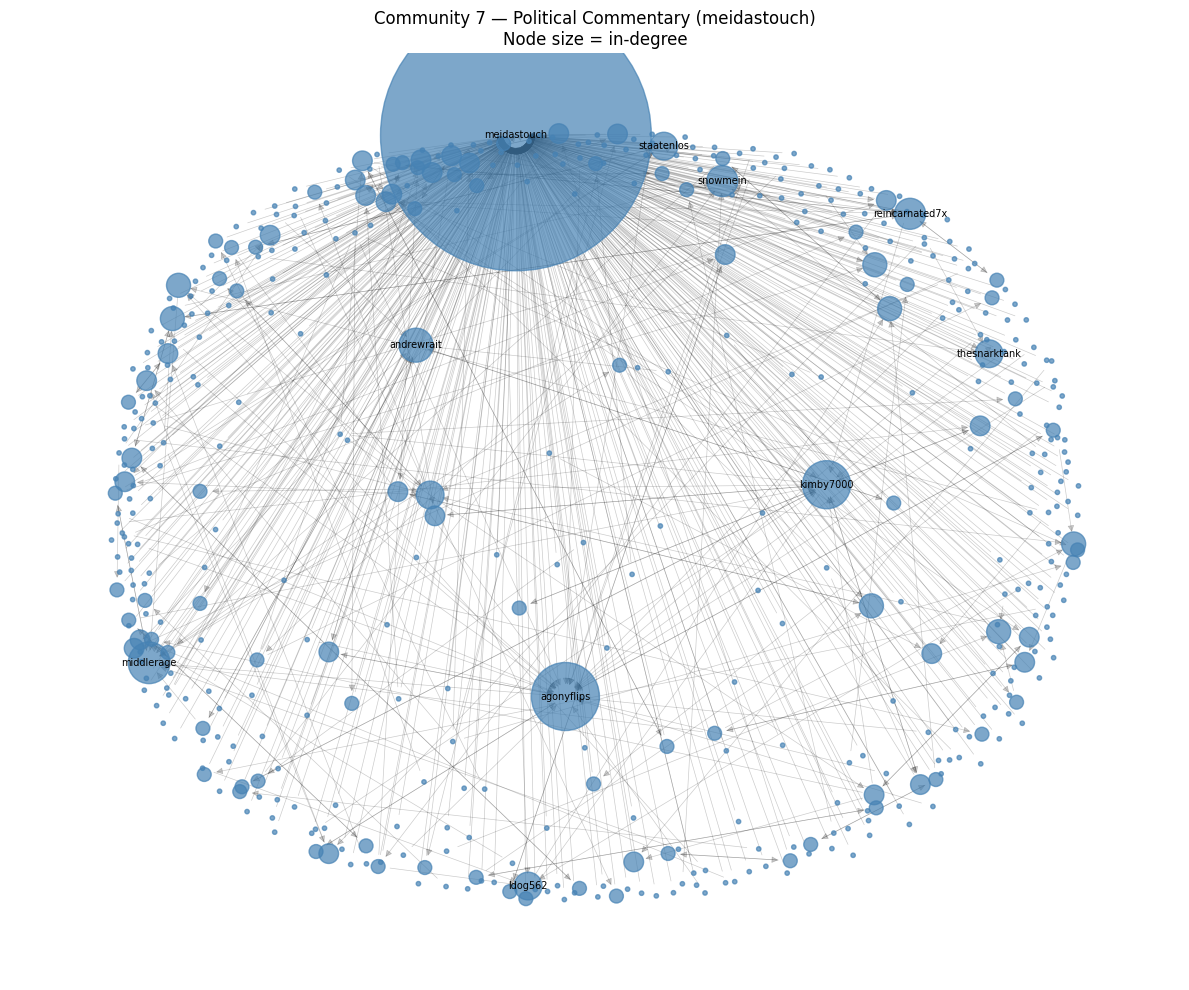

In [341]:
in_degrees_7 = dict(community_7_subgraph.in_degree())

node_sizes = [max(10, in_degrees_7.get(n, 0) * 100) for n in community_7_subgraph.nodes()]

pos = nx.spring_layout(community_7_subgraph, seed=42, k=0.8)

plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(community_7_subgraph, pos, node_size=node_sizes, 
                       node_color='steelblue', alpha=0.7)
nx.draw_networkx_edges(community_7_subgraph, pos, alpha=0.2, arrows=True, width=0.5)

# Label only top nodes
top_nodes_7 = sorted(in_degrees_7.items(), key=lambda x: x[1], reverse=True)[:10]
labels_7    = {node: node.split('.')[0] for node, deg in top_nodes_7}

nx.draw_networkx_labels(community_7_subgraph, pos, labels=labels_7, font_size=7)

plt.title("Community 7 — Political Commentary (meidastouch)\nNode size = in-degree")
plt.axis('off')
plt.tight_layout()
plt.savefig('community_7_subgraph.png', dpi=300, bbox_inches='tight')
plt.show()

In [343]:
# Get users in community 7
community_7_users = community_users.get(57, [])

# Create subgraph
community_7_subgraph = replyGraph.subgraph(community_7_users)

print(f"Nodes: {community_7_subgraph.number_of_nodes()}")
print(f"Edges: {community_7_subgraph.number_of_edges()}")
print(f"Density: {nx.density(community_7_subgraph):.4f}")

Nodes: 212
Edges: 302
Density: 0.0068


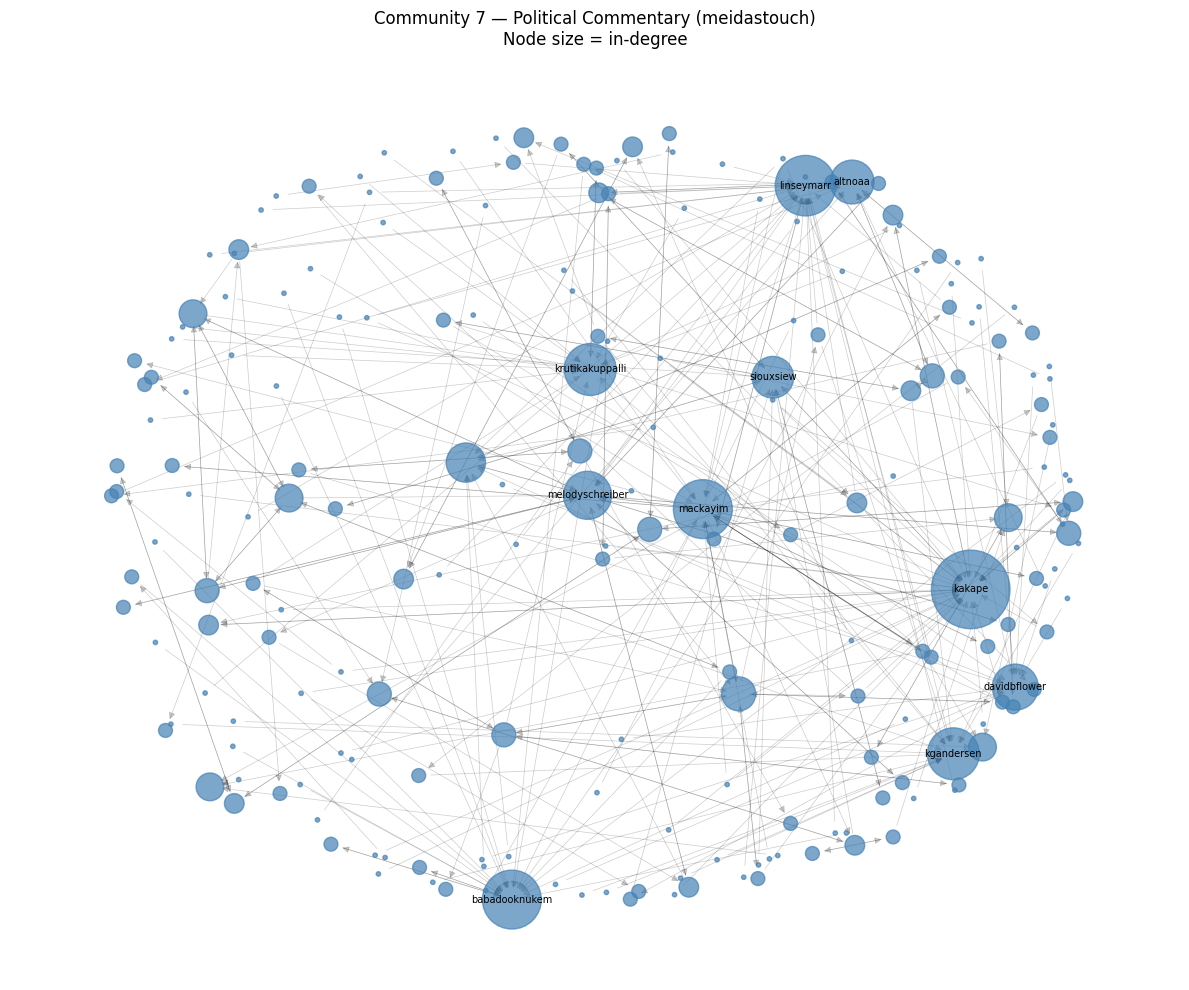

In [345]:
in_degrees_7 = dict(community_7_subgraph.in_degree())

node_sizes = [max(10, in_degrees_7.get(n, 0) * 100) for n in community_7_subgraph.nodes()]

pos = nx.spring_layout(community_7_subgraph, seed=42, k=0.8)

plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(community_7_subgraph, pos, node_size=node_sizes, 
                       node_color='steelblue', alpha=0.7)
nx.draw_networkx_edges(community_7_subgraph, pos, alpha=0.2, arrows=True, width=0.5)

# Label only top nodes
top_nodes_7 = sorted(in_degrees_7.items(), key=lambda x: x[1], reverse=True)[:10]
labels_7    = {node: node.split('.')[0] for node, deg in top_nodes_7}

nx.draw_networkx_labels(community_7_subgraph, pos, labels=labels_7, font_size=7)

plt.title("Community 7 — Political Commentary (meidastouch)\nNode size = in-degree")
plt.axis('off')
plt.tight_layout()
plt.savefig('community_7_subgraph.png', dpi=300, bbox_inches='tight')
plt.show()

In [347]:
# Get users in community 7
community_7_users = community_users.get(1, [])

# Create subgraph
community_7_subgraph = replyGraph.subgraph(community_7_users)

print(f"Nodes: {community_7_subgraph.number_of_nodes()}")
print(f"Edges: {community_7_subgraph.number_of_edges()}")
print(f"Density: {nx.density(community_7_subgraph):.4f}")

Nodes: 367
Edges: 412
Density: 0.0031


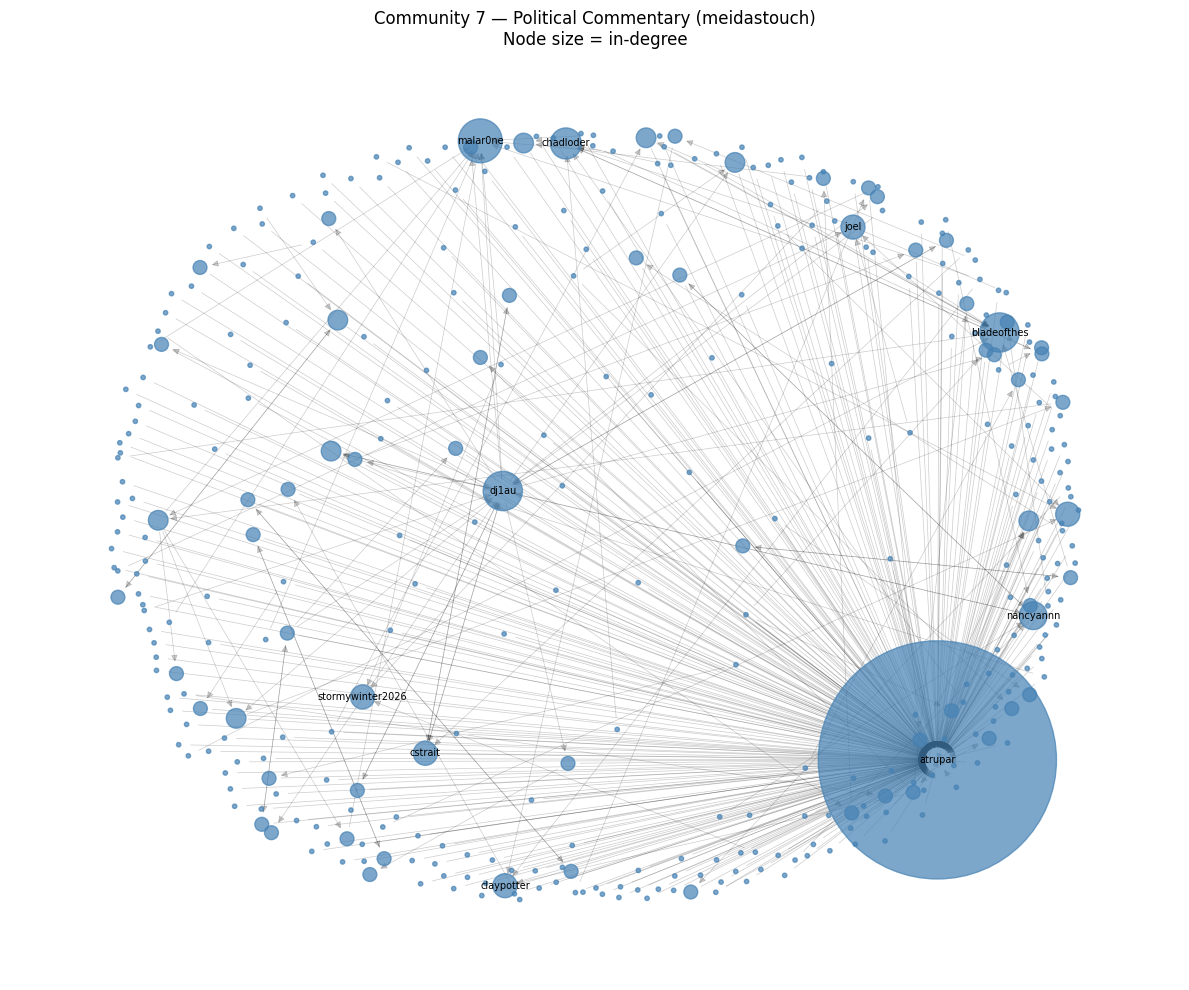

In [349]:
in_degrees_7 = dict(community_7_subgraph.in_degree())

node_sizes = [max(10, in_degrees_7.get(n, 0) * 100) for n in community_7_subgraph.nodes()]

pos = nx.spring_layout(community_7_subgraph, seed=42, k=0.8)

plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(community_7_subgraph, pos, node_size=node_sizes, 
                       node_color='steelblue', alpha=0.7)
nx.draw_networkx_edges(community_7_subgraph, pos, alpha=0.2, arrows=True, width=0.5)

# Label only top nodes
top_nodes_7 = sorted(in_degrees_7.items(), key=lambda x: x[1], reverse=True)[:10]
labels_7    = {node: node.split('.')[0] for node, deg in top_nodes_7}

nx.draw_networkx_labels(community_7_subgraph, pos, labels=labels_7, font_size=7)

plt.title("Community 7 — Political Commentary (meidastouch)\nNode size = in-degree")
plt.axis('off')
plt.tight_layout()
plt.savefig('community_7_subgraph.png', dpi=300, bbox_inches='tight')
plt.show()

In [351]:
# Get users in community 7
community_7_users = community_users.get(6, [])

# Create subgraph
community_7_subgraph = replyGraph.subgraph(community_7_users)

print(f"Nodes: {community_7_subgraph.number_of_nodes()}")
print(f"Edges: {community_7_subgraph.number_of_edges()}")
print(f"Density: {nx.density(community_7_subgraph):.4f}")

Nodes: 175
Edges: 177
Density: 0.0058


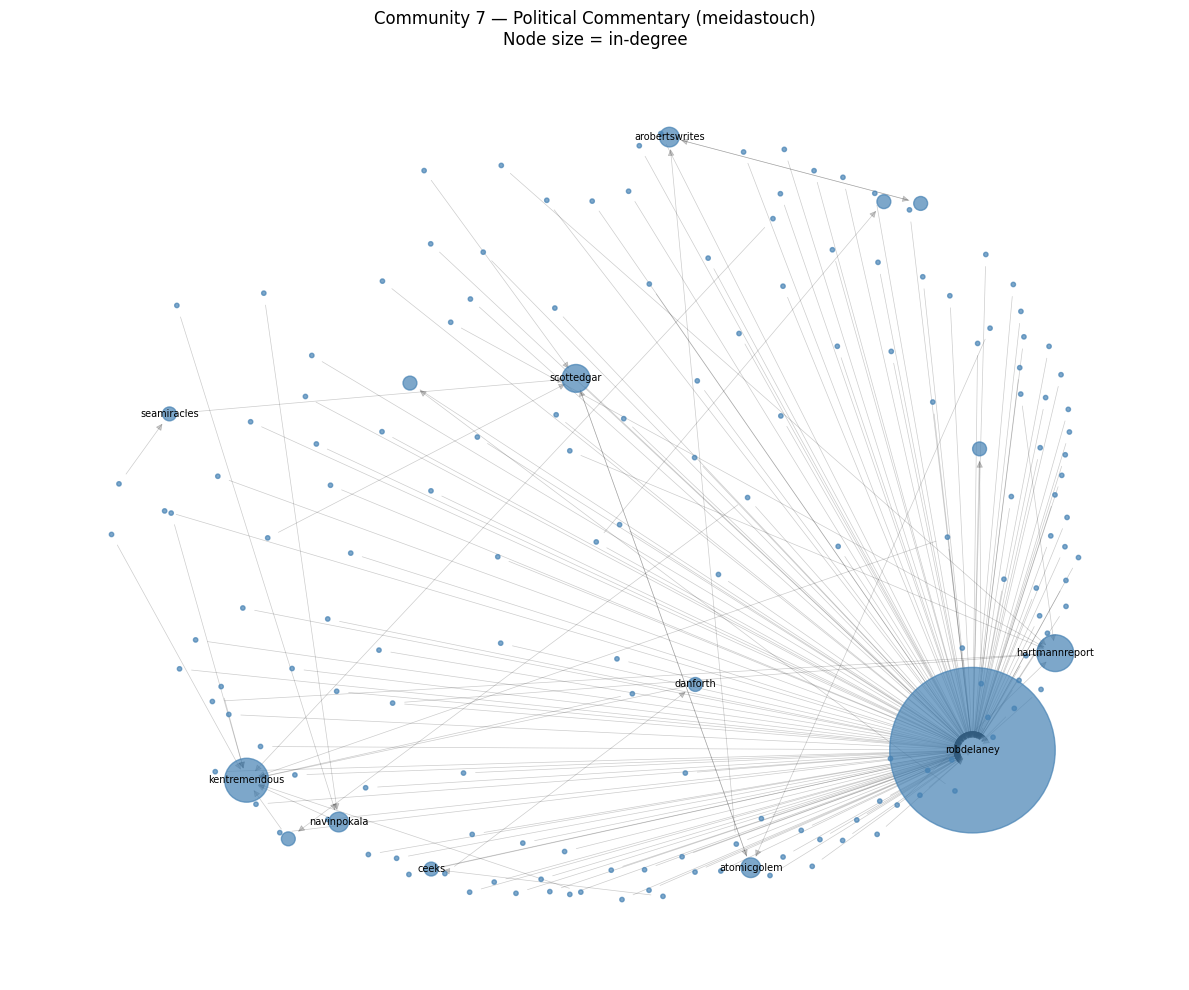

In [353]:
in_degrees_7 = dict(community_7_subgraph.in_degree())

node_sizes = [max(10, in_degrees_7.get(n, 0) * 100) for n in community_7_subgraph.nodes()]

pos = nx.spring_layout(community_7_subgraph, seed=42, k=0.8)

plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(community_7_subgraph, pos, node_size=node_sizes, 
                       node_color='steelblue', alpha=0.7)
nx.draw_networkx_edges(community_7_subgraph, pos, alpha=0.2, arrows=True, width=0.5)

# Label only top nodes
top_nodes_7 = sorted(in_degrees_7.items(), key=lambda x: x[1], reverse=True)[:10]
labels_7    = {node: node.split('.')[0] for node, deg in top_nodes_7}

nx.draw_networkx_labels(community_7_subgraph, pos, labels=labels_7, font_size=7)

plt.title("Community 7 — Political Commentary (meidastouch)\nNode size = in-degree")
plt.axis('off')
plt.tight_layout()
plt.savefig('community_7_subgraph.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Individual Community analysis
This section of code will seek to understand sentiment around the hantavirus specific to community types, and aim to see if influential figures have the same sentiment as the group and wheter their key terms match

#### Analysis 1 - Political commentary centered community

In [122]:
#Code Adapted from https://datascienceplus.com/evaluation-of-topic-modeling-topic-coherence/
#Method to calculate the coherence scores for k number of topics 
def compute_coherence_values(dictionary, corpus, texts, start=2, limit=10, step=1):
    coherence_values = [] #List to store the coherence scores
    models = [] #List of models
    #Use a seed to ensure reproducability over multiple runs 
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)

    #Train an LDA MODEL for k number of topics between the start and stop value
    for num_topics in range(start, limit, step):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10)
        models.append(model)

        #Calculate the coherence score for each model
        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v' )

        #Append cohenerence values to the list - to be used in plot
        coherence_values.append(coherencemodel.get_coherence())

    return models, coherence_values

In [215]:
community_7_posts = [post for post in hanta_posts if post[5] == 7]
len(community_7_posts)

737

In [118]:
#Term frequency counter
Community_7_comments = []

#Process each english comment
for post_author, post_text, post_date, post_likes, post_reposts, post_community in community_7_posts:
    #Filter out unicode characters (optional but keep for consistency)
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)

    #Process text
    lTokens = processText(
        text=post_text,
        tokenizer=tweetTokeniser,
        Lemma=lemmatizer,
        stopwords=lStopwords)

    Community_7_comments.append(lTokens)

In [108]:
#Bi-grams

In [124]:
#code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Create a dictionary mapping words to unique IDs from tokenized comments
dictionary = corpora.Dictionary(Community_7_comments)
#Convert tokenized documents into bag of words (BOW) representation
corpus = [dictionary.doc2bow(doc) for doc in Community_7_comments]

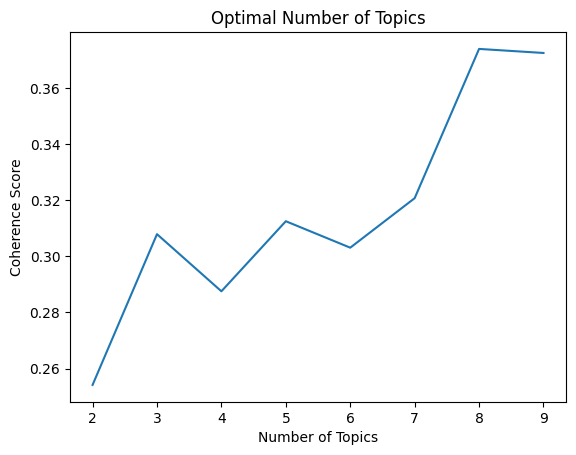

In [126]:
#Code adapted from: https://datascienceplus.com/evaluation-of-topic-modeling-topic-coherence/
#Run the method from above to calculate the coherence score of the LDA model for different k number of topics
#This code section may be slow to run.
models, coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=Community_7_comments,
    start=2,
    limit=10,
    step=1)

#Plot the coherence scores for k number of topics.
x = range(2, 10)
plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Optimal Number of Topics")
plt.show()

In [128]:
#Code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Train the LDA model with the optimal number of topics
lda_model = LdaModel(corpus, num_topics=8, id2word=dictionary,random_state=42, passes = 5)
#Print the topics
print(lda_model.print_topics())

[(0, '0.021*"trump" + 0.012*"people" + 0.010*"covid" + 0.010*"ship" + 0.010*"go" + 0.010*"get" + 0.010*"hantavirus" + 0.009*"cruise" + 0.008*"person" + 0.007*"come"'), (1, '0.018*"rfk" + 0.015*"jr" + 0.013*"ship" + 0.012*"another" + 0.012*"cruise" + 0.011*"get" + 0.010*"time" + 0.010*"covid" + 0.010*"sick" + 0.010*"go"'), (2, '0.016*"say" + 0.012*"human" + 0.010*"people" + 0.010*"worry" + 0.009*"covid" + 0.009*"cdc" + 0.008*"fuck" + 0.007*"anything" + 0.007*"kill" + 0.006*"jr"'), (3, '0.021*"ship" + 0.020*"cruise" + 0.013*"one" + 0.009*"leave" + 0.009*"spread" + 0.009*"disease" + 0.009*"covid" + 0.008*"cdc" + 0.008*"get" + 0.007*"american"'), (4, '0.018*"people" + 0.015*"center" + 0.014*"human" + 0.011*"go" + 0.010*"best" + 0.009*"nebraska" + 0.009*"outbreak" + 0.009*"place" + 0.008*"probably" + 0.008*"nebraskan"'), (5, '0.014*"go" + 0.011*"way" + 0.008*"well" + 0.008*"know" + 0.007*"hantavirus" + 0.006*"people" + 0.006*"shit" + 0.006*"fuck" + 0.006*"happen" + 0.005*"quarantine"'), (6,

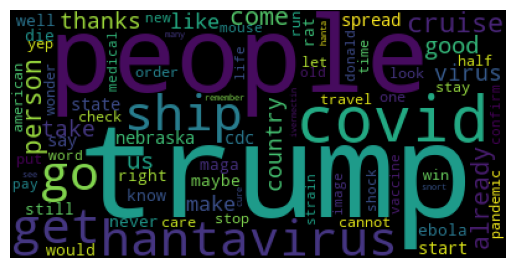

In [130]:
#Code adapted from: https://stackoverflow.com/questions/60993778/how-to-create-wordcloud-from-lda-model
#Create a word cloud for topic 0 - include top 75 words in topic
plt.imshow(WordCloud(random_state=42).fit_words(dict(lda_model.show_topic(0, 75))))
plt.axis("off")
plt.show() #Print the word cloud 

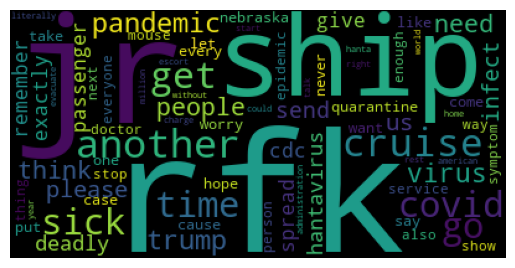

In [132]:
#Code adapted from: https://stackoverflow.com/questions/60993778/how-to-create-wordcloud-from-lda-model
#Create a word cloud for topic 1 - include top 75 words in topic
plt.imshow(WordCloud(random_state=42).fit_words(dict(lda_model.show_topic(1, 75))))
plt.axis("off")
plt.show() #Print the word cloud 

In [323]:
#Overall sentiment

In [ ]:
# Preprocess central user posts
comm7_SA_comments = []

for post_author, post_text, post_date, post_likes, post_reposts, post_community in community_7_posts:
    clean_text = clean_for_sentiment(post_text)
    lTokens    = processTextSA(
        text=clean_text,
        tokenizer=tweetTokeniser,
        stopwords=lStopwords
    )
    comm7_SA_comments.append([post_date, lTokens])

lSentimentVDR = [] #To hold returned list of comments with [date,sentiment]
lSentimentVDR = vaderSentimentAnalysis1(comm7_SA_comments, flagPrint) #Run and caluclate Vader Sentiment analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

# Convert date column safely (handles mixed + timezone-aware formats)
series['date'] = pd.to_datetime(
    series['date'],
    errors='coerce',
    utc=True
)

# Optional: remove timezone (convert to naive datetime)
series['date'] = series['date'].dt.tz_convert(None)

# Set index for resampling
series.set_index('date', inplace=True)

# Ensure sentiment is numeric
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

# Resample hourly and compute mean sentiment
newSeries = series.resample('1D').mean()

# Plot
newSeries.plot(legend=False)

plt.title("Average Vader Sentiment Score By Hour")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

In [134]:
#Sentiment

In [253]:
# Define your four representative communities and central users
representative_communities = {
    7:  {'central_user': 'meidastouch.com',          'type': 'Political Commentary'},
    49: {'central_user': 'apnews.com',                'type': 'Traditional Media'},
    57: {'central_user': 'kakape.bsky.social',        'type': 'Science/Public Health'},
}

In [255]:
target_comm_id = 7
central_user = 'meidastouch.com'
# Posts by central figure in this community
central_user_posts = []

# Posts by everyone else in this community
other_posts = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:
    if post_community == target_comm_id:
        if post_author == central_user:
            central_user_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])
        else:
            other_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])

In [257]:
# Preprocess central user posts
central_SA_comments = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in central_user_posts:
    clean_text = clean_for_sentiment(post_text)
    lTokens = processTextSA(text=clean_text,
                            tokenizer=tweetTokeniser,
                            stopwords=lStopwords)
    central_SA_comments.append([post_date, lTokens])

# Preprocess rest of community posts
other_SA_comments = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in other_posts:
    clean_text = clean_for_sentiment(post_text)
    lTokens = processTextSA(text=clean_text, 
                            tokenizer=tweetTokeniser,
                            stopwords=lStopwords)
    other_SA_comments.append([post_date, lTokens])

In [263]:
central_sentiment = vaderSentimentAnalysis1(central_SA_comments, flagPrint)
other_sentiment   = vaderSentimentAnalysis1(other_SA_comments, flagPrint)

Central user sentiment scores: 4
Other community sentiment scores: 729


In [265]:
# Central user average
central_scores = [s for date, s in central_sentiment]
central_avg    = sum(central_scores) / len(central_scores) if central_scores else 0
central_label  = "Positive" if central_avg >= 0.05 else "Negative" if central_avg <= -0.05 else "Neutral"
central_pos    = sum(1 for s in central_scores if s >= 0.05)         / len(central_scores) * 100
central_neu    = sum(1 for s in central_scores if -0.05 < s < 0.05)  / len(central_scores) * 100
central_neg    = sum(1 for s in central_scores if s <= -0.05)        / len(central_scores) * 100

# Rest of community average
other_scores   = [s for date, s in other_sentiment]
other_avg      = sum(other_scores) / len(other_scores) if other_scores else 0
other_label    = "Positive" if other_avg >= 0.05 else "Negative" if other_avg <= -0.05 else "Neutral"
other_pos      = sum(1 for s in other_scores if s >= 0.05)           / len(other_scores) * 100
other_neu      = sum(1 for s in other_scores if -0.05 < s < 0.05)    / len(other_scores) * 100
other_neg      = sum(1 for s in other_scores if s <= -0.05)          / len(other_scores) * 100

# Alignment
diff = abs(central_avg - other_avg)
if diff < 0.05:
    alignment = "Strongly aligned"
elif diff < 0.15:
    alignment = "Moderately aligned"
else:
    alignment = "Divergent"

# Print comparison
print(f"\n--- Community {target_comm_id} — {comm_type} ---")
print(f"\nCentral User: {central_user}")
print(f"  Avg sentiment: {central_avg:.4f} ({central_label})")
print(f"  Positive: {central_pos:.1f}%  Neutral: {central_neu:.1f}%  Negative: {central_neg:.1f}%")
print(f"\nRest of Community:")
print(f"  Avg sentiment: {other_avg:.4f} ({other_label})")
print(f"  Positive: {other_pos:.1f}%  Neutral: {other_neu:.1f}%  Negative: {other_neg:.1f}%")
print(f"\nAlignment: {alignment} (difference: {diff:.4f})")


--- Community 7 — Science/Public Health ---

Central User: meidastouch.com
  Avg sentiment: -0.1256 (Negative)
  Positive: 25.0%  Neutral: 25.0%  Negative: 50.0%

Rest of Community:
  Avg sentiment: -0.0049 (Neutral)
  Positive: 36.4%  Neutral: 27.7%  Negative: 35.9%

Alignment: Moderately aligned (difference: 0.1207)


---
#### Public Health Community Group

In [151]:
c57_posts = [post for post in hanta_posts if post[5] == 57]
len(c57_posts)

Total posts in community 1: 604


In [153]:
#Term frequency counter
c57_comments = []

#Process each english comment
for post_author, post_text, post_date, post_likes, post_reposts, post_community in c57_posts:
    #Filter out unicode characters (optional but keep for consistency)
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)

    #Process text
    lTokens = processText(
        text=post_text,
        tokenizer=tweetTokeniser,
        Lemma=lemmatizer,
        stopwords=lStopwords)

    c57_comments.append(lTokens)

In [155]:
#code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Create a dictionary mapping words to unique IDs from tokenized comments
dictionary = corpora.Dictionary(c57_comments)
#Convert tokenized documents into bag of words (BOW) representation
corpus = [dictionary.doc2bow(doc) for doc in c57_comments]

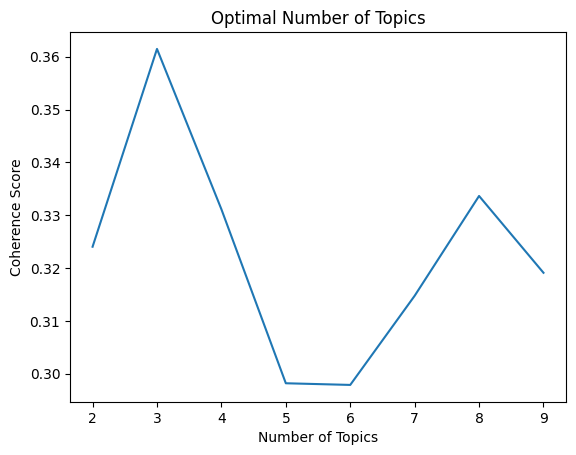

In [157]:
#Code adapted from: https://datascienceplus.com/evaluation-of-topic-modeling-topic-coherence/
#Run the method from above to calculate the coherence score of the LDA model for different k number of topics
#This code section may be slow to run.
models, coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=Community_7_comments,
    start=2,
    limit=10,
    step=1)

#Plot the coherence scores for k number of topics.
x = range(2, 10)
plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Optimal Number of Topics")
plt.show()

In [167]:
#Code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Train the LDA model with the optimal number of topics
lda_model = LdaModel(corpus, num_topics=3, id2word=dictionary,random_state=42, passes = 5)
#Print the topics
print(lda_model.print_topics())

[(0, '0.009*"case" + 0.009*"outbreak" + 0.009*"virus" + 0.008*"hantavirus" + 0.007*"go" + 0.007*"andes" + 0.007*"ship" + 0.006*"may" + 0.006*"one" + 0.006*"mean"'), (1, '0.021*"ship" + 0.015*"outbreak" + 0.014*"cruise" + 0.012*"hantavirus" + 0.007*"like" + 0.006*"know" + 0.006*"passenger" + 0.005*"get" + 0.005*"say" + 0.005*"may"'), (2, '0.010*"spread" + 0.009*"human" + 0.008*"virus" + 0.008*"covid" + 0.007*"test" + 0.007*"people" + 0.007*"like" + 0.007*"one" + 0.007*"case" + 0.007*"mask"')]


In [311]:
# Preprocess central user posts
c57_Vader_SA = []

for post_author, post_text, post_date, post_likes, post_reposts, post_community in c57_posts:
    clean_text = clean_for_sentiment(post_text)
    lTokens = processTextSA(text=clean_text,
                            tokenizer=tweetTokeniser,
                            stopwords=lStopwords)
    c57_Vader_SA.append([post_date, lTokens])

lSentimentVDR = [] #To hold returned list of comments with [date,sentiment]
lSentimentVDR = vaderSentimentAnalysis1(c57_Vader_SA, flagPrint) #Run and caluclate Vader Sentiment analysis

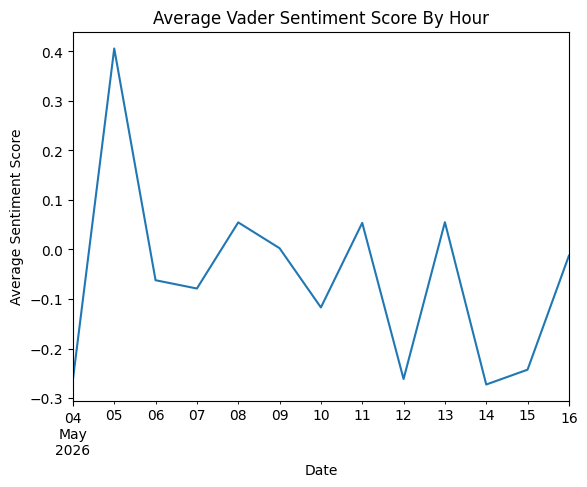

In [321]:
# Create DataFrame
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

# Convert date column safely (handles mixed + timezone-aware formats)
series['date'] = pd.to_datetime(
    series['date'],
    errors='coerce',
    utc=True
)

# Optional: remove timezone (convert to naive datetime)
series['date'] = series['date'].dt.tz_convert(None)

# Set index for resampling
series.set_index('date', inplace=True)

# Ensure sentiment is numeric
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

# Resample hourly and compute mean sentiment
newSeries = series.resample('1D').mean()

# Plot
newSeries.plot(legend=False)

plt.title("Average Vader Sentiment Score By Hour")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

In [159]:
# Define your four representative communities and central users
representative_communities = {
    7:  {'central_user': 'meidastouch.com',          'type': 'Political Commentary'},
    49: {'central_user': 'apnews.com',                'type': 'Traditional Media'},
    57: {'central_user': 'kakape.bsky.social',        'type': 'Science/Public Health'},}

Analysing Community 57 — Science/Public Health
Central User: kakape.bsky.social


In [ ]:
target_comm_id = 57
central_user = 'kakape.bsky.social'
# Posts by central figure in this community
central_user_posts = []

# Posts by everyone else in this community
other_posts = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:
    if post_community == target_comm_id:
        if post_author == central_user:
            central_user_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])
        else:
            other_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])

In [160]:
# Posts by central figure in this community
central_user_posts = []

# Posts by everyone else in this community
other_posts = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:
    if post_community == target_comm_id:
        if post_author == central_user:
            central_user_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])
        else:
            other_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])

Posts by kakape.bsky.social: 28
Posts by rest of community: 575


In [169]:
# Preprocess central user posts
central_SA_comments = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in central_user_posts:
    clean_text = clean_for_sentiment(post_text)
    lTokens    = processTextSA(
        text=clean_text,
        tokenizer=tweetTokeniser,
        stopwords=lStopwords
    )
    central_SA_comments.append([post_date, lTokens])

# Preprocess rest of community posts
other_SA_comments = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in other_posts:
    clean_text = clean_for_sentiment(post_text)
    lTokens    = processTextSA(
        text=clean_text,
        tokenizer=tweetTokeniser,
        stopwords=lStopwords
    )
    other_SA_comments.append([post_date, lTokens])

Central user preprocessed posts: 28
Other community preprocessed posts: 575


In [171]:


# Run VADER
central_sentiment = vaderSentimentAnalysis1(central_SA_comments, flagPrint)
other_sentiment   = vaderSentimentAnalysis1(other_SA_comments,   flagPrint)

Central user sentiment scores: 28
Other community sentiment scores: 575


In [173]:
# Central user average
central_scores = [s for date, s in central_sentiment]
central_avg    = sum(central_scores) / len(central_scores) if central_scores else 0
central_label  = "Positive" if central_avg >= 0.05 else "Negative" if central_avg <= -0.05 else "Neutral"
central_pos    = sum(1 for s in central_scores if s >= 0.05)         / len(central_scores) * 100
central_neu    = sum(1 for s in central_scores if -0.05 < s < 0.05)  / len(central_scores) * 100
central_neg    = sum(1 for s in central_scores if s <= -0.05)        / len(central_scores) * 100

# Rest of community average
other_scores   = [s for date, s in other_sentiment]
other_avg      = sum(other_scores) / len(other_scores) if other_scores else 0
other_label    = "Positive" if other_avg >= 0.05 else "Negative" if other_avg <= -0.05 else "Neutral"
other_pos      = sum(1 for s in other_scores if s >= 0.05)           / len(other_scores) * 100
other_neu      = sum(1 for s in other_scores if -0.05 < s < 0.05)    / len(other_scores) * 100
other_neg      = sum(1 for s in other_scores if s <= -0.05)          / len(other_scores) * 100

# Alignment
diff = abs(central_avg - other_avg)
if diff < 0.05:
    alignment = "Strongly aligned"
elif diff < 0.15:
    alignment = "Moderately aligned"
else:
    alignment = "Divergent"

# Print comparison
print(f"\n--- Community {target_comm_id} — {comm_type} ---")
print(f"\nCentral User: {central_user}")
print(f"  Avg sentiment: {central_avg:.4f} ({central_label})")
print(f"  Positive: {central_pos:.1f}%  Neutral: {central_neu:.1f}%  Negative: {central_neg:.1f}%")
print(f"\nRest of Community:")
print(f"  Avg sentiment: {other_avg:.4f} ({other_label})")
print(f"  Positive: {other_pos:.1f}%  Neutral: {other_neu:.1f}%  Negative: {other_neg:.1f}%")
print(f"\nAlignment: {alignment} (difference: {diff:.4f})")


--- Community 57 — Science/Public Health ---

Central User: kakape.bsky.social
  Avg sentiment: 0.1822 (Positive)
  Positive: 64.3%  Neutral: 10.7%  Negative: 25.0%

Rest of Community:
  Avg sentiment: 0.0936 (Positive)
  Positive: 45.7%  Neutral: 24.2%  Negative: 30.1%

Alignment: Moderately aligned (difference: 0.0887)


---
#### Another Health Community

In [177]:
c162_posts = [post for post in hanta_posts if post[5] == 162]
len(c162_posts)

Total posts in community 1: 512


In [179]:
#Term frequency counter
c162_comments = []

#Process each english comment
for post_author, post_text, post_date, post_likes, post_reposts, post_community in c162_posts:
    #Filter out unicode characters (optional but keep for consistency)
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)

    #Process text
    lTokens = processText(
        text=post_text,
        tokenizer=tweetTokeniser,
        Lemma=lemmatizer,
        stopwords=lStopwords)

    c162_comments.append(lTokens)

In [181]:
#code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Create a dictionary mapping words to unique IDs from tokenized comments
dictionary = corpora.Dictionary(c162_comments)
#Convert tokenized documents into bag of words (BOW) representation
corpus = [dictionary.doc2bow(doc) for doc in c162_comments]

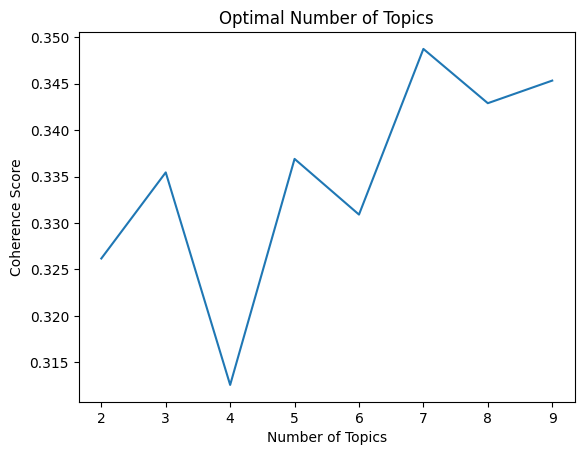

In [183]:
#Code adapted from: https://datascienceplus.com/evaluation-of-topic-modeling-topic-coherence/
#Run the method from above to calculate the coherence score of the LDA model for different k number of topics
#This code section may be slow to run.
models, coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=Community_7_comments,
    start=2,
    limit=10,
    step=1)

#Plot the coherence scores for k number of topics.
x = range(2, 10)
plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Optimal Number of Topics")
plt.show()

In [187]:
#Code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Train the LDA model with the optimal number of topics
lda_model = LdaModel(corpus, num_topics=7, id2word=dictionary,random_state=42, passes = 5)
#Print the topics
print(lda_model.print_topics())

[(0, '0.018*"human" + 0.017*"transmission" + 0.012*"virus" + 0.012*"hantavirus" + 0.009*"contact" + 0.008*"spread" + 0.008*"thanks" + 0.007*"ship" + 0.007*"see" + 0.007*"one"'), (1, '0.018*"ship" + 0.011*"people" + 0.011*"hantavirus" + 0.010*"cruise" + 0.010*"say" + 0.010*"know" + 0.009*"think" + 0.007*"virus" + 0.007*"outbreak" + 0.007*"covid"'), (2, '0.012*"hantavirus" + 0.012*"public" + 0.011*"health" + 0.007*"say" + 0.005*"right" + 0.005*"get" + 0.005*"test" + 0.005*"sure" + 0.005*"one" + 0.005*"yeah"'), (3, '0.013*"hantavirus" + 0.011*"ship" + 0.010*"outbreak" + 0.009*"know" + 0.008*"people" + 0.008*"us" + 0.007*"cruise" + 0.007*"pandemic" + 0.007*"never" + 0.006*"covid"'), (4, '0.010*"go" + 0.010*"outbreak" + 0.009*"hantavirus" + 0.008*"work" + 0.008*"virus" + 0.008*"case" + 0.006*"cruise" + 0.005*"ship" + 0.005*"us" + 0.005*"say"'), (5, '0.012*"say" + 0.010*"know" + 0.009*"get" + 0.009*"ship" + 0.009*"quarantine" + 0.008*"public" + 0.008*"think" + 0.007*"go" + 0.007*"people" + 0

In [ ]:
# Preprocess central user posts
c162_SA_comments = []

for post_author, post_text, post_date, post_likes, post_reposts, post_community in c162_posts:
    clean_text = clean_for_sentiment(post_text)
    lTokens    = processTextSA(
        text=clean_text,
        tokenizer=tweetTokeniser,
        stopwords=lStopwords
    )
    c162_SA_comments.append([post_date, lTokens])

lSentimentVDR = [] #To hold returned list of comments with [date,sentiment]
lSentimentVDR = vaderSentimentAnalysis1(c162_SA_comments, flagPrint) #Run and caluclate Vader Sentiment analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

# Convert date column safely (handles mixed + timezone-aware formats)
series['date'] = pd.to_datetime(
    series['date'],
    errors='coerce',
    utc=True
)

# Optional: remove timezone (convert to naive datetime)
series['date'] = series['date'].dt.tz_convert(None)

# Set index for resampling
series.set_index('date', inplace=True)

# Ensure sentiment is numeric
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

# Resample hourly and compute mean sentiment
newSeries = series.resample('1D').mean()

# Plot
newSeries.plot(legend=False)

plt.title("Average Vader Sentiment Score By Hour")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

In [ ]:
target_comm_id = 162
central_user = 'elizabethjacobs.bsky.social'
# Posts by central figure in this community
central_user_posts = []

# Posts by everyone else in this community
other_posts = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:
    if post_community == target_comm_id:
        if post_author == central_user:
            central_user_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])
        else:
            other_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])

In [191]:
# Posts by central figure in this community
central_user_posts = []

# Posts by everyone else in this community
other_posts = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:
    if post_community == target_comm_id:
        if post_author == central_user:
            central_user_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])
        else:
            other_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community])

Posts by elizabethjacobs.bsky.social: 27
Posts by rest of community: 484


In [195]:
# Preprocess central user posts
central_SA_comments = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in central_user_posts:
    clean_text = clean_for_sentiment(post_text)
    lTokens    = processTextSA(
        text=clean_text,
        tokenizer=tweetTokeniser,
        stopwords=lStopwords
    )
    central_SA_comments.append([post_date, lTokens])

# Preprocess rest of community posts
other_SA_comments = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in other_posts:
    clean_text = clean_for_sentiment(post_text)
    lTokens    = processTextSA(
        text=clean_text,
        tokenizer=tweetTokeniser,
        stopwords=lStopwords
    )
    other_SA_comments.append([post_date, lTokens])

Central user preprocessed posts: 27
Other community preprocessed posts: 484


In [197]:
# Run VADER
central_sentiment = vaderSentimentAnalysisSimple1(central_SA_comments, flagPrint)
other_sentiment   = vaderSentimentAnalysisSimple1(other_SA_comments,   flagPrint)

Central user sentiment scores: 27
Other community sentiment scores: 484


In [199]:
# Central user average
central_scores = [s for date, s in central_sentiment]
central_avg    = sum(central_scores) / len(central_scores) if central_scores else 0
central_label  = "Positive" if central_avg >= 0.05 else "Negative" if central_avg <= -0.05 else "Neutral"
central_pos    = sum(1 for s in central_scores if s >= 0.05)         / len(central_scores) * 100
central_neu    = sum(1 for s in central_scores if -0.05 < s < 0.05)  / len(central_scores) * 100
central_neg    = sum(1 for s in central_scores if s <= -0.05)        / len(central_scores) * 100

# Rest of community average
other_scores   = [s for date, s in other_sentiment]
other_avg      = sum(other_scores) / len(other_scores) if other_scores else 0
other_label    = "Positive" if other_avg >= 0.05 else "Negative" if other_avg <= -0.05 else "Neutral"
other_pos      = sum(1 for s in other_scores if s >= 0.05)           / len(other_scores) * 100
other_neu      = sum(1 for s in other_scores if -0.05 < s < 0.05)    / len(other_scores) * 100
other_neg      = sum(1 for s in other_scores if s <= -0.05)          / len(other_scores) * 100

# Alignment
diff = abs(central_avg - other_avg)
if diff < 0.05:
    alignment = "Strongly aligned"
elif diff < 0.15:
    alignment = "Moderately aligned"
else:
    alignment = "Divergent"

# Print comparison
print(f"\n--- Community {target_comm_id} — {comm_type} ---")
print(f"\nCentral User: {central_user}")
print(f"  Avg sentiment: {central_avg:.4f} ({central_label})")
print(f"  Positive: {central_pos:.1f}%  Neutral: {central_neu:.1f}%  Negative: {central_neg:.1f}%")
print(f"\nRest of Community:")
print(f"  Avg sentiment: {other_avg:.4f} ({other_label})")
print(f"  Positive: {other_pos:.1f}%  Neutral: {other_neu:.1f}%  Negative: {other_neg:.1f}%")
print(f"\nAlignment: {alignment} (difference: {diff:.4f})")


--- Community 162 — Science/Public Health ---

Central User: elizabethjacobs.bsky.social
  Avg sentiment: 0.1231 (Positive)
  Positive: 48.1%  Neutral: 25.9%  Negative: 25.9%

Rest of Community:
  Avg sentiment: 0.0446 (Neutral)
  Positive: 42.4%  Neutral: 25.0%  Negative: 32.6%

Alignment: Moderately aligned (difference: 0.0785)


In [203]:
# Get users in community 7
community_7_users = community_users.get(162, [])

# Create subgraph
community_7_subgraph = replyGraph.subgraph(community_7_users)

print(f"Nodes: {community_7_subgraph.number_of_nodes()}")
print(f"Edges: {community_7_subgraph.number_of_edges()}")
print(f"Density: {nx.density(community_7_subgraph):.4f}")

Nodes: 207
Edges: 274
Density: 0.0064


In [336]:
#RANDOM CRAP

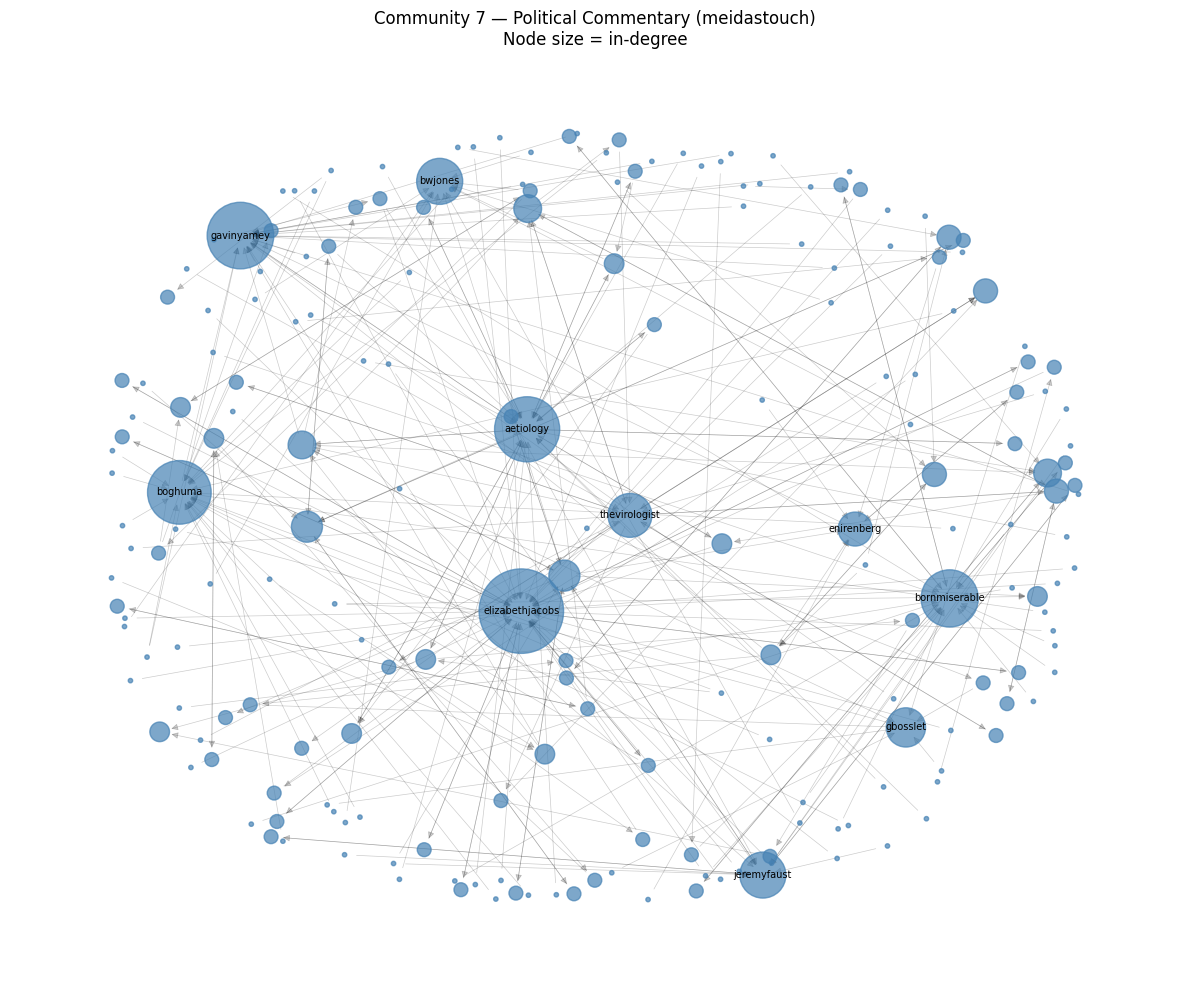

In [205]:
in_degrees_7 = dict(community_7_subgraph.in_degree())

node_sizes = [max(10, in_degrees_7.get(n, 0) * 100) for n in community_7_subgraph.nodes()]

pos = nx.spring_layout(community_7_subgraph, seed=42, k=0.8)

plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(community_7_subgraph, pos, node_size=node_sizes, 
                       node_color='steelblue', alpha=0.7)
nx.draw_networkx_edges(community_7_subgraph, pos, alpha=0.2, arrows=True, width=0.5)

# Label only top nodes
top_nodes_7 = sorted(in_degrees_7.items(), key=lambda x: x[1], reverse=True)[:10]
labels_7    = {node: node.split('.')[0] for node, deg in top_nodes_7}

nx.draw_networkx_labels(community_7_subgraph, pos, labels=labels_7, font_size=7)

plt.title("Community 7 — Political Commentary (meidastouch)\nNode size = in-degree")
plt.axis('off')
plt.tight_layout()
plt.savefig('community_7_subgraph.png', dpi=300, bbox_inches='tight')
plt.show()

In [207]:
# Get users in community 7
community_7_users = community_users.get(7, [])

# Create subgraph
community_7_subgraph = replyGraph.subgraph(community_7_users)

print(f"Nodes: {community_7_subgraph.number_of_nodes()}")
print(f"Edges: {community_7_subgraph.number_of_edges()}")
print(f"Density: {nx.density(community_7_subgraph):.4f}")

Nodes: 493
Edges: 603
Density: 0.0025


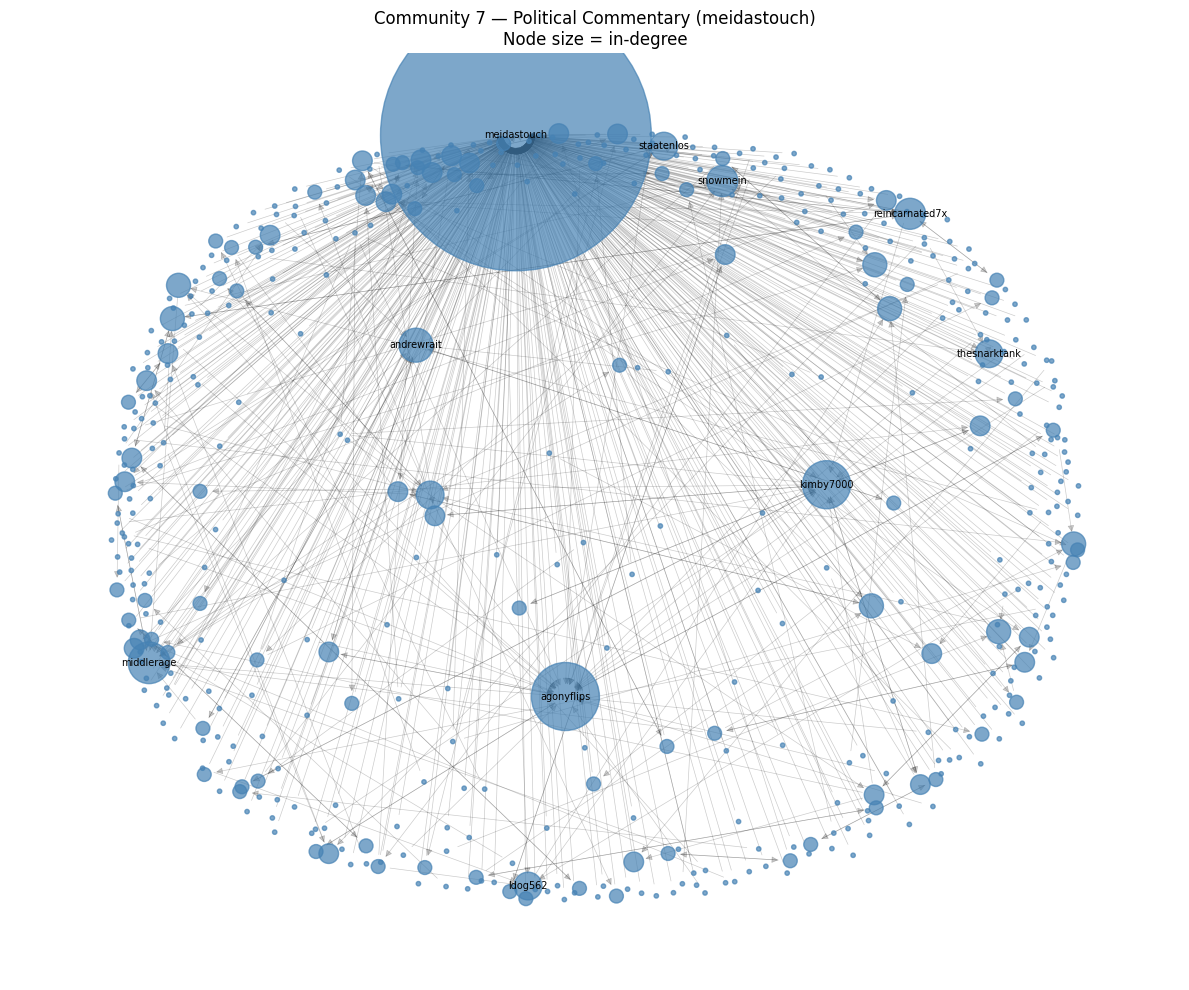

In [209]:
in_degrees_7 = dict(community_7_subgraph.in_degree())

node_sizes = [max(10, in_degrees_7.get(n, 0) * 100) for n in community_7_subgraph.nodes()]

pos = nx.spring_layout(community_7_subgraph, seed=42, k=0.8)

plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(community_7_subgraph, pos, node_size=node_sizes, 
                       node_color='steelblue', alpha=0.7)
nx.draw_networkx_edges(community_7_subgraph, pos, alpha=0.2, arrows=True, width=0.5)

# Label only top nodes
top_nodes_7 = sorted(in_degrees_7.items(), key=lambda x: x[1], reverse=True)[:10]
labels_7    = {node: node.split('.')[0] for node, deg in top_nodes_7}

nx.draw_networkx_labels(community_7_subgraph, pos, labels=labels_7, font_size=7)

plt.title("Community 7 — Political Commentary (meidastouch)\nNode size = in-degree")
plt.axis('off')
plt.tight_layout()
plt.savefig('community_7_subgraph.png', dpi=300, bbox_inches='tight')
plt.show()

---
#### News community

In [326]:
community_7_posts = [post for post in hanta_posts if post[5] == 49]
len(community_7_posts)

1

----
#### General chat community